# Reinforcement Learning for Robotic Task Recognition in Event-Driven Environments

This project will implement a **Reinforcement Learning (RL)** algorithm to enable a **robotic arm** to interact with the right box based on observable events. The objective is to develop an RL-based system in which a robot can recognize and respond to **complex, sequential decision-making scenarios** within a dynamic, event-driven environment. Specifically, the robot will control a robotic arm that reacts to these changing situations.

To achieve this, we will use **simulations like PyBullet** for robotic tasks and the **Open the Chests (OtC) environment** to tackle complex sequential decision-making challenges. The Open the Chests environment provides a **sequential event-based world** where the robot can observe and make informed decisions. Meanwhile, PyBullet will be used to **simulate the control of a robotic arm**, enabling it to physically respond to situations and manipulate objects.

The project combines two ideas:

1. **Robotic control in simulation** using **PyBullet** and a custom KUKA environment.
2. **Event-driven decision making** using the **Open the Chests** environment.

Your overall goal is to design a system that can:

- observe its environment,
- recognize useful patterns,
- decide which chest should be opened,
- and move the robotic arm to the correct target.

## Relevant Documentation and Libraries

To better understand and implement the project, the following resources and libraries are recommended:

### Reinforcement Learning Libraries:
- **Stable Baselines3**: RL framework with pre-implemented algorithms. [📖 Documentation](https://stable-baselines3.readthedocs.io/en/master/)
- **Gymnasium (formerly OpenAI Gym)**: Toolkit for developing RL environments. [📖 Documentation](https://gymnasium.farama.org/)
- **RL Baselines3 Zoo**: Collection of pre-trained RL agents. [📖 GitHub](https://github.com/DLR-RM/rl-baselines3-zoo)

### Robotic Simulation:
- **PyBullet**: Physics engine for robotic simulations. [📖 Documentation](https://pybullet.org/) [📖 Quicktart Guide](https://docs.google.com/document/d/10sXEhzFRSnvFcl3XxNGhnD4N2SedqwdAvK3dsihxVUA/edit?tab=t.0)


### Open the Chests (OtC) Environment:
- **OtC Environment Overview**: Sequential event-based RL scenario. [📖  GitHub ](https://github.com/ThalesGroup/open-the-chests) [📖 Article ](https://drops.dagstuhl.de/entities/document/10.4230/LIPIcs.TIME.2024.5) [📖 Presentation ](https://www.lirmm.fr/time2024/files/OpenTheChestsTIME2024.pdf)

## Project roadmap and expected outcomes

By the end of the project, your notebook or report should contain clear evidence for all three parts.

### Task 1: Robotic control in PyBullet
Build and test an RL agent that can move the KUKA arm toward the correct colored chest.

*Suggested analysis* : You should show that you can load the KUKA environment, explain the state/action/reward setup, and evaluate a controller. It's recommended to provide analysis and comparisons during training to highlight your understanding of the process. For example, provide multiple curves on different training setups you made and explain the difference between the two.

### Task 2: Event recognition in Open the Chests
Study how event sequences of increasing complexity determine which chest should be opened.

*Suggested analysis* : You should compare the easy, medium, and hard Open the Chests settings and explain which cases require memory or temporal reasoning. Explain in which settings the algorithm struggles and why. For example, provide a visualisation of the embeddings of a trained model and explain its capacity to cluster activities.

### Task 3: Combine the two environments
Connect event recognition to robotic control so that one component identifies the correct chest and another component executes the motion.

*Suggested analysis* : You should explain how the event-recognition module tells the robot-control module which chest to open, and you should include at least one evaluation result, visualization, or pipeline design. Currently the two systems are separated, suggest a possible combination and explain possible advantages/disadvantages.

## Files used in this project

This notebook assumes the provided file `colored_chest_kuka_env.py` and `register_envs.py` are available in the same working directory.

In [ ]:
# Install the main libraries used across the full project.
# If you already have these packages, this cell is safe to skip.

!pip install -q gymnasium pybullet stable-baselines3 matplotlib imageio imageio-ffmpeg

print("Dependencies installed.")

In [ ]:
!conda install -y -c conda-forge pybullet

In [ ]:
!where python3

In [ ]:
import sys
print(sys.executable)

In [5]:
import sys
print(sys.version)

3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]


In [ ]:
!pip install stable-baselines3 matplotlib imageio imageio-ffmpeg

In [ ]:
!pip install git+https://github.com/ThalesGroup/open-the-chests.git@0.7.5

## 1. RL Environment with PyBullet

## Goal
The objective of this section is to **use a RL environment** using **PyBullet**, where a robotic arm learns to **reach for a specific chest** based on input commands. The robot must **autonomously decide and execute movements** to successfully complete the task.


## Suggested Approach

A reasonable workflow is:

- start with a **random-policy sanity check**,
- inspect the reward and success signal,
- train a baseline controller such as **PPO**,
- then evaluate whether the robot reaches the correct chest reliably,
- if needed, modify reward shaping or model parameters and make ablations to compare the difference

*Attention: You may modify the environment file if needed to test different reward functions.*

## Summary of the Environment

`ColoredChestKukaEnv` is a robotic manipulation reinforcement learning environment built around a **KUKA robotic arm** interacting with **colored chests** in a simulated scene. The agent learns to control the robot so it interacts with the correct chest based on the task configuration.

### Environment State (Observation)

Observations returned by the environment describe the current physical configuration of the robot and the objects. The observation vector typically includes values derived from variables such as:

- **End-effector position** (from the robot state, typically retrieved using the robot link state).
- **Chest positions**, stored internally in variables such as `self.chest_positions`.
- **Target color information**, usually stored in a variable like `self.target_color`.
- **Robot joint states or gripper state**, depending on the configuration.

These values are aggregated and returned by the `_get_obs()` method, which constructs the observation returned at each `step()`.

### Action Space

The agent acts through the environment's `action_space`, which controls the **movement of the robot end-effector**.

Typical actions include:
- $\delta x$, $\delta y$, $\delta z$ movements applied to the end-effector
- optional gripper control

Actions are processed in the `step(self, action)` method, where they are converted into robot motion commands applied to the KUKA arm in the simulation.

### Reward Computation

Rewards are computed inside the `step()` function using environment variables such as:

- `self.target_color`
- chest positions stored in `self.chest_positions`
- the robot end-effector position

The reward generally reflects:
- **distance between the end-effector and the correct chest**
- **successful interaction with the chest matching `self.target_color`**

This may involve distance calculations and success checks implemented in helper logic inside `step()`.

### Episode Termination

Episodes terminate when one of the following conditions occurs:

- **Task success**: the robot correctly interacts with the chest corresponding to `self.target_color`.
- **Maximum number of steps**: tracked internally (commonly via a counter such as `self.step_count` or similar).
- **Environment constraints violated** (depending on implementation).

Termination flags are returned by the `step()` method as `terminated` or `truncated`.

### Reset Behavior

The `reset()` method initializes a new episode by:

- resetting the simulation
- placing the robot back in its **initial pose**
- randomly or deterministically assigning chest positions (`self.chest_positions`)
- sampling the **target color** (`self.target_color`)

This ensures that each episode begins from a consistent starting state.

### Rendering

Rendering is supported through the environment’s `render()` method. When enabled, it visualizes:

- the **KUKA robotic arm**
- the **colored chests**
- the current manipulation attempt

Rendering is mainly used for debugging, demonstrations, or visualizing trained policies.

In [1]:
# Core Gymnasium API
import gymnasium as gym

# Import the module that contains ColoredChestKukaEnv.
# This is important because the `register(...)` call inside that file
# only runs when the module is imported.
import colored_chest_kuka_env

# Utilities for building an in-memory GIF so we can display it inline
# without writing a video or gif file to disk.
import io
import imageio

# IPython display tools for showing the animation directly in the notebook.
from IPython.display import Image, display

pybullet build time: Oct 21 2025 10:25:59


In [2]:
import imageio
import numpy as np
from IPython.display import Video

In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

In [4]:
import os
import numpy as np
import gymnasium as gym


In [5]:
# Create the environment through Gymnasium's registry.
#
# Important arguments:
# - render_mode="rgb_array":
#   required when you want rendered frames as NumPy arrays, which is the
#   standard mode for notebook/Colab visualizations.
#
# - reward_type="advanced":
#   uses the environment's more detailed reward logic, assuming your env
#   supports this keyword argument.
#
# - max_steps=150:
#   sets the per-episode step budget if your environment constructor accepts it.
env = gym.make(
    "ColoredChestKuka-v0",
    render_mode="rgb_array",
    reward_type="advanced",
    max_steps=150,
)

# Reset the environment to obtain the initial observation and info dictionary.
obs, info = env.reset()

# Print a few useful details so you can quickly verify the environment loaded
# as expected and inspect its spaces.
print("Environment created successfully.")
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Initial info:", info)

Environment created successfully.
Observation space: Box(-inf, inf, (10,), float32)
Action space: Box(-0.05, 0.05, (3,), float32)
Initial info: {'target_idx': 2, 'target_color_rgba': [0.0, 0.0, 1.0, 1.0]}


In [ ]:
# This list will store the rendered frames returned by env.render().
# Each frame is usually a NumPy array of shape (H, W, 3).
frames = []

# Number of random actions to try.
# You can increase this if you want a longer animation.
num_steps = 80

# Reset once more so the rollout starts from a clean initial state.
obs, info = env.reset()

for step_idx in range(num_steps):
    # Render the current state BEFORE taking the action, so the first frame
    # shows the initial configuration of the scene.
    frame = env.render()
    frames.append(frame)

    # Sample a random valid action from the environment's action space.
    # This is useful for smoke-testing that stepping and rendering work.
    action = env.action_space.sample()

    # Apply the action to the environment.
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"obs={obs}, reward={reward}, terminated={terminated}, truncated={truncated}, info={info}")

    # Optional debug print for quick inspection during development.
    # print(
    #    f"step={step_idx:03d} | reward={reward:.3f} | "
    #    f"terminated={terminated} | truncated={truncated}"
    #)

    # Stop the rollout cleanly if the episode has ended.
    if terminated or truncated:
        # Capture one final frame after the terminal transition so the
        # animation includes the end state.
        frames.append(env.render())
        print("Episode finished early.")
        break

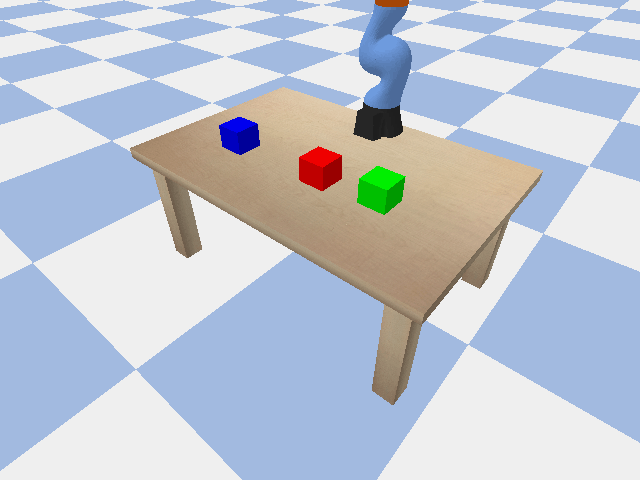

In [7]:
# Build a GIF fully in memory using BytesIO.
# This avoids saving any file such as "kuka_demo.gif" to disk.
gif_buffer = io.BytesIO()

# `imageio.mimsave` writes the animated GIF into the in-memory buffer.
# `format="GIF"` is specified explicitly for clarity.
#
# `fps=12` controls playback speed:
# - lower value -> slower animation
# - higher value -> faster animation
imageio.mimsave(gif_buffer, frames, format="GIF", fps=144)

# Rewind the buffer to the beginning before reading its bytes.
gif_buffer.seek(0)

# Display the GIF directly in the notebook output.
display(Image(data=gif_buffer.getvalue()))

In [8]:
# This cell reuses the `frames` list collected earlier and writes an MP4
# in a Colab-friendly way, then embeds it directly in the notebook output.

import imageio
import numpy as np
from IPython.display import Video

video_path = "kuka_episode.mp4"

# Ensure every frame is a NumPy array with uint8 dtype, which video encoders expect.
frames_np = [np.asarray(f, dtype=np.uint8) for f in frames]

# Write the MP4 video.
# macro_block_size=None avoids automatic resizing warnings/errors for odd frame sizes.
imageio.mimsave(
    video_path,
    frames_np,
    fps=20,
    codec="libx264",
    macro_block_size=None,
)

print("Video generated:", video_path)

# In Colab, embed=True is usually necessary for the video to display correctly.
Video(video_path, embed=True)#

Video generated: kuka_episode.mp4


In [9]:
# Always close the environment when finished.
# This is especially important for simulation-based environments.
env.close()
print("Environment closed.")

Environment closed.


## Putting the following code into its context

This work is part of the team's project

This notebook aims to study different configurations of the PPO training and provide the best model for the final task 3

At the end of the notebook we dive deeper into comparing basic reward shaping and advanced reward shaping and we provide a histogramm plot comparing the success rate of different trained models.

Finally we provide an evaluation that loads the model and show the demo of a successful episode

## PPO Grid Search: Training + Evaluation (Requested Hyperparameters)
This section runs a full sweep over your requested PPO hyperparameters and both reward modes (`basic`, `advanced`).



### 20 hand-picked stage-1 configs 

Manually defined to maximize coverage of the most important axes

In [ ]:
import os
import csv
import time

import numpy as np
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv

In [ ]:

STAGE1_CONFIGS = [
    # reward_type  n_steps  lr      batch  gamma   ent_coef  clip  n_epochs
    # --- basic reward, sweep lr and n_steps ---
    ("basic",    1024,  3e-4,   64,   0.99,  0.0,   0.2,  10),
    ("basic",    1024,  1e-4,   64,   0.99,  0.0,   0.2,  10),
    ("basic",    2048,  3e-4,   64,   0.99,  0.0,   0.2,  10),
    ("basic",    2048,  1e-4,   64,   0.99,  0.0,   0.2,  10),
    # --- basic reward, entropy effect ---
    ("basic",    1024,  3e-4,   64,   0.99,  0.01,  0.2,  10),
    ("basic",    2048,  3e-4,   64,   0.99,  0.01,  0.2,  10),
    # --- basic reward, tighter clip ---
    ("basic",    1024,  3e-4,   64,   0.99,  0.0,   0.1,  10),
    ("basic",    2048,  3e-4,   64,   0.99,  0.0,   0.1,  10),
    # --- basic reward, larger batch ---
    ("basic",    1024,  3e-4,  128,   0.99,  0.0,   0.2,  10),
    ("basic",    2048,  3e-4,  128,   0.99,  0.0,   0.2,  10),
    # --- advanced reward, sweep lr and n_steps ---
    ("advanced", 1024,  3e-4,   64,   0.99,  0.0,   0.2,  10),
    ("advanced", 1024,  1e-4,   64,   0.99,  0.0,   0.2,  10),
    ("advanced", 2048,  3e-4,   64,   0.99,  0.0,   0.2,  10),
    ("advanced", 2048,  1e-4,   64,   0.99,  0.0,   0.2,  10),
    # --- advanced reward, entropy effect ---
    ("advanced", 1024,  3e-4,   64,   0.99,  0.01,  0.2,  10),
    ("advanced", 2048,  3e-4,   64,   0.99,  0.01,  0.2,  10),
    # --- advanced reward, tighter clip ---
    ("advanced", 1024,  3e-4,   64,   0.99,  0.0,   0.1,  10),
    ("advanced", 2048,  3e-4,   64,   0.99,  0.0,   0.1,  10),
    # --- advanced reward, higher gamma (long-horizon) ---
    ("advanced", 1024,  3e-4,   64,  0.995,  0.0,   0.2,  10),
    ("advanced", 2048,  3e-4,   64,  0.995,  0.0,   0.2,  10),
]

### Stage settings 

In [ ]:
STAGE1_TIMESTEPS     = 300_000
STAGE2_TIMESTEPS     = 1_500_000
STAGE1_EVAL_EPISODES = 100
STAGE2_EVAL_EPISODES = 100
STAGE1_TOP_K         = 3
STAGE2_SEEDS         = [42]

###  Parallelism 

DummyVecEnv avoids Jupyter/Colab multiprocessing issues.

In [ ]:
N_ENVS = 4

### Network architecture 

In [ ]:
POLICY_KWARGS = dict(net_arch=dict(pi=[256, 256], vf=[256, 256]))

### Misc

In [ ]:
VERBOSE               = 0
MAX_STEPS_PER_EPISODE = 150

SAVE_DIR   = "saved_kuka_models_grid"
STAGE1_CSV = os.path.join(SAVE_DIR, "stage1_results.csv")
STAGE2_CSV = os.path.join(SAVE_DIR, "stage2_results.csv")
os.makedirs(SAVE_DIR, exist_ok=True)

FIELDNAMES_BASE = [
    "run_name", "reward_type", "n_steps", "learning_rate", "batch_size",
    "gamma", "ent_coef", "clip_range", "n_epochs",
    "total_timesteps", "train_seconds",
    "mean_reward", "success_rate", "num_successes", "num_eval_episodes",
    "model_path",
]
STAGE2_FIELDNAMES = FIELDNAMES_BASE + ["seed"]

### Helpers

In [ ]:
def _safe_float_tag(value: float) -> str:
    return str(value).replace(".", "p")


def cfg_from_tuple(t: tuple, idx: int) -> dict:
    reward_type, n_steps, lr, batch_size, gamma, ent_coef, clip_range, n_epochs = t
    return dict(
        reward_type=reward_type,
        n_steps=n_steps,
        learning_rate=lr,
        batch_size=batch_size,
        gamma=gamma,
        ent_coef=ent_coef,
        clip_range=clip_range,
        n_epochs=n_epochs,
        run_name=(
            f"run_{idx:02d}_"
            f"reward-{reward_type}_"
            f"nsteps-{n_steps}_"
            f"lr-{_safe_float_tag(lr)}_"
            f"batch-{batch_size}_"
            f"gamma-{_safe_float_tag(gamma)}_"
            f"ent-{_safe_float_tag(ent_coef)}_"
            f"clip-{_safe_float_tag(clip_range)}_"
            f"nepochs-{n_epochs}"
        ),
    )


def make_env_fn(reward_type: str):
    def _init():
        import colored_chest_kuka_env
        import gymnasium as gym
        env = gym.make(
            "ColoredChestKuka-v0",
            render_mode=None,
            reward_type=reward_type,
            max_steps=MAX_STEPS_PER_EPISODE,
        )
        return Monitor(env)
    return _init


def make_vec_env(reward_type: str, n_envs: int) -> DummyVecEnv:
    return DummyVecEnv([make_env_fn(reward_type) for _ in range(n_envs)])


def evaluate_model(model: PPO, reward_type: str, num_eval_episodes: int) -> tuple[float, float, int]:
    eval_env = gym.make(
        "ColoredChestKuka-v0",
        render_mode=None,
        reward_type=reward_type,
        max_steps=MAX_STEPS_PER_EPISODE,
    )
    episode_rewards, successes = [], []

    for _ in range(num_eval_episodes):
        obs, info = eval_env.reset()
        done = truncated = False
        total_reward = 0.0
        while not done and not truncated:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = eval_env.step(action)
            total_reward += reward
        episode_rewards.append(total_reward)
        successes.append(int(info.get("is_success", False)))

    eval_env.close()
    return float(np.mean(episode_rewards)), float(np.mean(successes)), int(np.sum(successes))


def load_completed_run_names(csv_path: str) -> set:
    if not os.path.exists(csv_path):
        return set()
    with open(csv_path, "r", newline="") as f:
        return {row["run_name"] for row in csv.DictReader(f)}


def load_csv_rows(csv_path: str) -> list[dict]:
    if not os.path.exists(csv_path):
        return []
    with open(csv_path, "r", newline="") as f:
        return list(csv.DictReader(f))


def append_result_row(csv_path: str, fieldnames: list, row: dict):
    file_exists = os.path.exists(csv_path)
    with open(csv_path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        if not file_exists:
            writer.writeheader()
        writer.writerow(row)


def train_model(cfg: dict, total_timesteps: int, seed: int) -> tuple[PPO, float]:
    vec_env = make_vec_env(cfg["reward_type"], N_ENVS)

    model = PPO(
        policy="MlpPolicy",
        env=vec_env,
        verbose=VERBOSE,
        seed=seed,
        learning_rate=cfg["learning_rate"],
        n_steps=cfg["n_steps"],
        batch_size=cfg["batch_size"],
        gamma=cfg["gamma"],
        ent_coef=cfg["ent_coef"],
        clip_range=cfg["clip_range"],
        n_epochs=cfg["n_epochs"],
        policy_kwargs=POLICY_KWARGS,
    )
    start = time.time()
    model.learn(total_timesteps=total_timesteps)
    elapsed = time.time() - start

    vec_env.close()
    return model, round(elapsed, 2)

### Stage 1: 20 configs

In [ ]:
def run_stage1() -> list[dict]:
    total = len(STAGE1_CONFIGS)

    print(f"\n{'='*60}")
    print(f"STAGE 1 — {total} configs × 1 seed × {STAGE1_TIMESTEPS:,} steps")
    print(f"Estimated time: ~{total * 6} min  |  N_ENVS={N_ENVS} (DummyVecEnv)")
    print(f"{'='*60}\n")

    completed = load_completed_run_names(STAGE1_CSV)
    print(f"Already completed: {len(completed)}\n")

    results = load_csv_rows(STAGE1_CSV)
    for r in results:
        r["success_rate"] = float(r["success_rate"])
        r["mean_reward"]  = float(r["mean_reward"])

    for idx, combo in enumerate(STAGE1_CONFIGS, 1):
        cfg = cfg_from_tuple(combo, idx)
        run_name   = cfg["run_name"]
        model_path = os.path.join(SAVE_DIR, f"s1_{run_name}.zip")

        if run_name in completed:
            print(f"[{idx}/{total}] Skip (done): {run_name}")
            continue

        eta = (total - idx + 1) * 6
        print(f"[{idx}/{total}] {run_name}  (ETA remaining: ~{eta} min)")

        model, train_seconds = train_model(cfg, STAGE1_TIMESTEPS, seed=42)
        model.save(model_path)

        mean_reward, success_rate, num_successes = evaluate_model(
            model, cfg["reward_type"], STAGE1_EVAL_EPISODES
        )

        row = {
            "run_name":          run_name,
            "reward_type":       cfg["reward_type"],
            "n_steps":           cfg["n_steps"],
            "learning_rate":     cfg["learning_rate"],
            "batch_size":        cfg["batch_size"],
            "gamma":             cfg["gamma"],
            "ent_coef":          cfg["ent_coef"],
            "clip_range":        cfg["clip_range"],
            "n_epochs":          cfg["n_epochs"],
            "total_timesteps":   STAGE1_TIMESTEPS,
            "train_seconds":     train_seconds,
            "mean_reward":       mean_reward,
            "success_rate":      success_rate,
            "num_successes":     num_successes,
            "num_eval_episodes": STAGE1_EVAL_EPISODES,
            "model_path":        model_path,
        }
        append_result_row(STAGE1_CSV, FIELDNAMES_BASE, row)
        results.append(row)

        print(f"  → mean_reward={mean_reward:.3f} | success_rate={success_rate:.3f} | {train_seconds:.0f}s\n")

    print(f"Stage 1 complete. Results → {STAGE1_CSV}")
    return results

### Top-K selection

In [ ]:
def pick_top_k(stage1_results: list[dict], k: int) -> list[dict]:
    sorted_results = sorted(
        stage1_results,
        key=lambda r: (float(r["success_rate"]), float(r["mean_reward"])),
        reverse=True,
    )
    top = sorted_results[:k]

    print(f"\n{'='*60}")
    print(f"Top {k} configs promoted to Stage 2 (1.5M steps, 3 seeds):")
    print(f"{'='*60}")
    for i, r in enumerate(top, 1):
        print(
            f"  {i}. success_rate={float(r['success_rate']):.3f} "
            f"| mean_reward={float(r['mean_reward']):.3f} "
            f"| {r['run_name']}"
        )
    return top

### Stage 2: top-3

In [ ]:
def run_stage2(top_configs: list[dict]):
    total = len(top_configs) * len(STAGE2_SEEDS)

    print(f"\n{'='*60}")
    print(f"STAGE 2 — {len(top_configs)} configs × {len(STAGE2_SEEDS)} seeds × {STAGE2_TIMESTEPS:,} steps")
    print(f"Total runs: {total}")
    print(f"{'='*60}\n")

    completed = load_completed_run_names(STAGE2_CSV)
    run_count  = 0

    for cfg_row in top_configs:
        for seed in STAGE2_SEEDS:
            run_count   += 1
            s2_run_name  = f"s2_{cfg_row['run_name']}_seed{seed}"
            model_path   = os.path.join(SAVE_DIR, f"{s2_run_name}.zip")

            if s2_run_name in completed:
                print(f"[{run_count}/{total}] Skip (done): {s2_run_name}")
                continue

            cfg = dict(
                reward_type=cfg_row["reward_type"],
                n_steps=int(cfg_row["n_steps"]),
                learning_rate=float(cfg_row["learning_rate"]),
                batch_size=int(cfg_row["batch_size"]),
                gamma=float(cfg_row["gamma"]),
                ent_coef=float(cfg_row["ent_coef"]),
                clip_range=float(cfg_row["clip_range"]),
                n_epochs=int(cfg_row["n_epochs"]),
            )

            print(f"[{run_count}/{total}] {s2_run_name}")
            model, train_seconds = train_model(cfg, STAGE2_TIMESTEPS, seed)
            model.save(model_path)

            mean_reward, success_rate, num_successes = evaluate_model(
                model, cfg["reward_type"], STAGE2_EVAL_EPISODES
            )

            row = {
                "run_name":          s2_run_name,
                "reward_type":       cfg["reward_type"],
                "n_steps":           cfg["n_steps"],
                "learning_rate":     cfg["learning_rate"],
                "batch_size":        cfg["batch_size"],
                "gamma":             cfg["gamma"],
                "ent_coef":          cfg["ent_coef"],
                "clip_range":        cfg["clip_range"],
                "n_epochs":          cfg["n_epochs"],
                "total_timesteps":   STAGE2_TIMESTEPS,
                "train_seconds":     train_seconds,
                "mean_reward":       mean_reward,
                "success_rate":      success_rate,
                "num_successes":     num_successes,
                "num_eval_episodes": STAGE2_EVAL_EPISODES,
                "model_path":        model_path,
                "seed":              seed,
            }
            append_result_row(STAGE2_CSV, STAGE2_FIELDNAMES, row)

            print(f"  → mean_reward={mean_reward:.3f} | success_rate={success_rate:.3f} | {train_seconds:.0f}s\n")

    print(f"Stage 2 complete. Results → {STAGE2_CSV}")

### Final leaderboard

In [ ]:
def summarize_stage2():
    rows = load_csv_rows(STAGE2_CSV)
    if not rows:
        print("No Stage 2 results found.")
        return

    from collections import defaultdict
    scores  = defaultdict(list)
    rewards = defaultdict(list)

    for row in rows:
        base = row["run_name"].rsplit("_seed", 1)[0]
        scores[base].append(float(row["success_rate"]))
        rewards[base].append(float(row["mean_reward"]))

    ranked = sorted(scores.items(), key=lambda x: np.mean(x[1]), reverse=True)

    print(f"\n{'='*60}")
    print("STAGE 2 LEADERBOARD")
    print(f"{'='*60}")
    print(f"  {'success_rate':<22} {'mean_reward':<14} config")
    print(f"  {'-'*56}")
    for base, sr_list in ranked:
        rw_list = rewards[base]
        print(
            f"  {np.mean(sr_list):.3f} ± {np.std(sr_list):.3f}          "
            f"{np.mean(rw_list):>8.3f}       {base}"
        )


### Entry point 

In [ ]:
if __name__ == "__main__":
    stage1_results = run_stage1()
    top_configs    = pick_top_k(stage1_results, k=STAGE1_TOP_K)
    run_stage2(top_configs)
    summarize_stage2()


STAGE 1 — 20 configs × 1 seed × 300,000 steps
Estimated time: ~120 min  |  N_ENVS=4 (DummyVecEnv)

Already completed: 0

[1/20] run_01_reward-basic_nsteps-1024_lr-0p0003_batch-64_gamma-0p99_ent-0p0_clip-0p2_nepochs-10  (ETA remaining: ~120 min)


pybullet build time: Oct 21 2025 10:25:59
/home/ensta/ensta-arous/miniconda3/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


  → mean_reward=-31.812 | success_rate=0.200 | 332s

[2/20] run_02_reward-basic_nsteps-1024_lr-0p0001_batch-64_gamma-0p99_ent-0p0_clip-0p2_nepochs-10  (ETA remaining: ~114 min)
  → mean_reward=-37.395 | success_rate=0.050 | 286s

[3/20] run_03_reward-basic_nsteps-2048_lr-0p0003_batch-64_gamma-0p99_ent-0p0_clip-0p2_nepochs-10  (ETA remaining: ~108 min)
  → mean_reward=-36.736 | success_rate=0.100 | 290s

[4/20] run_04_reward-basic_nsteps-2048_lr-0p0001_batch-64_gamma-0p99_ent-0p0_clip-0p2_nepochs-10  (ETA remaining: ~102 min)
  → mean_reward=-35.215 | success_rate=0.130 | 289s

[5/20] run_05_reward-basic_nsteps-1024_lr-0p0003_batch-64_gamma-0p99_ent-0p01_clip-0p2_nepochs-10  (ETA remaining: ~96 min)
  → mean_reward=-35.012 | success_rate=0.130 | 292s

[6/20] run_06_reward-basic_nsteps-2048_lr-0p0003_batch-64_gamma-0p99_ent-0p01_clip-0p2_nepochs-10  (ETA remaining: ~90 min)
  → mean_reward=-39.043 | success_rate=0.090 | 327s

[7/20] run_07_reward-basic_nsteps-1024_lr-0p0003_batch-64_gamm

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Stage 1 results analysis

The results in "saved_kuka_grid/stage1_results.csv" indicate that while the **"advanced" reward structure** generates significantly higher and strictly positive mean rewards compared to the "basic" structure, the peak success rates between the two formulations are remarkably similar. Across all twenty trials, **Run 17** (advanced reward) achieved the highest overall success rate at 31%, closely followed by **Run 07** (basic reward) at 30%. A distinct hyperparameter trend defines these top performers: both utilized a shorter rollout length (`n_steps=1024`) combined with a tighter clipping range (`clip_range=0.1`). This suggests the agent learns most effectively with more frequent gradient updates and stricter policy constraints, whereas variations in learning rate, batch size, or entropy coefficients had a less pronounced or consistent impact on the final success rate.

## stage 2 results analysis

The extended training data at 1.5 million timesteps reveals a dramatic divergence in performance between the two reward structures. While both top candidates from the initial grid search (`run_17` and `run_07`) utilized the optimal hyperparameter pairing of shorter rollouts (`n_steps=1024`) and tighter clipping (`clip_range=0.1`), only the **"advanced" reward structure (Run 17)** successfully scaled with more training time, achieving a dominant 47% success rate and a high mean reward of 211.57. In stark contrast, the **"basic" reward structure (Run 07)** actually degraded to a 13% success rate despite identical training conditions, demonstrating that without the refined reward shaping of the advanced formulation, the agent's learning plateaus and destabilizes over extended periods.

# Sweeping checkpoints with the best config from stage 2 (basic/advanced)

In [ ]:
import os
import csv
import time
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv

### Best config from stage 2

In [ ]:
BEST_CFG = dict(
    n_steps       = 1024,
    learning_rate = 3e-4,
    batch_size    = 64,
    gamma         = 0.99,
    ent_coef      = 0.0,
    clip_range    = 0.1,
    n_epochs      = 10,
)

### Checkpoints at which we evaluate (total env steps)

In [ ]:
CHECKPOINTS = [100_000, 200_000, 300_000, 500_000, 750_000, 1_000_000, 1_500_000]

### Eval / training settings

In [ ]:
NUM_EVAL_EPISODES = 100
MAX_STEPS         = 150
SEED              = 42
N_ENVS            = 4
POLICY_KWARGS     = dict(net_arch=dict(pi=[256, 256], vf=[256, 256]))

### Output paths (separate folder from previous experiments)

In [ ]:
SAVE_DIR  = "best_config_training"
CSV_PATH  = os.path.join(SAVE_DIR, "best_config_results.csv")
PLOT_PATH = os.path.join(SAVE_DIR, "best_config_sr_over_time.png")
os.makedirs(SAVE_DIR, exist_ok=True)

CSV_FIELDNAMES = [
    "reward_type", "timestep",
    "success_rate", "num_eval_episodes",
    "n_steps", "learning_rate", "batch_size",
    "gamma", "ent_coef", "clip_range", "n_epochs",
    "model_path", "wall_seconds",
]

### Helpers

In [ ]:
def make_env_fn(reward_type: str):
    def _init():
        import colored_chest_kuka_env
        import gymnasium as gym
        env = gym.make(
            "ColoredChestKuka-v0",
            render_mode=None,
            reward_type=reward_type,
            max_steps=MAX_STEPS,
        )
        return Monitor(env)
    return _init


def make_vec_env(reward_type: str) -> DummyVecEnv:
    return DummyVecEnv([make_env_fn(reward_type) for _ in range(N_ENVS)])


def evaluate(model: PPO, reward_type: str) -> float:
    eval_env = gym.make(
        "ColoredChestKuka-v0",
        render_mode=None,
        reward_type=reward_type,
        max_steps=MAX_STEPS,
    )
    successes = []
    for _ in range(NUM_EVAL_EPISODES):
        obs, info = eval_env.reset()
        done = truncated = False
        while not done and not truncated:
            action, _ = model.predict(obs, deterministic=True)
            obs, _, done, truncated, info = eval_env.step(action)
        successes.append(int(info.get("is_success", False)))
    eval_env.close()
    return float(np.mean(successes))


def append_csv_row(row: dict):
    file_exists = os.path.exists(CSV_PATH)
    with open(CSV_PATH, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=CSV_FIELDNAMES)
        if not file_exists:
            writer.writeheader()
        writer.writerow(row)


def load_completed(reward_type: str) -> set[int]:
    """Returns set of already-evaluated timesteps for a given reward_type."""
    if not os.path.exists(CSV_PATH):
        return set()
    with open(CSV_PATH, "r", newline="") as f:
        return {
            int(row["timestep"])
            for row in csv.DictReader(f)
            if row["reward_type"] == reward_type
        }

### Training loop

In [ ]:
def train_with_checkpoints(reward_type: str) -> dict[int, float]:
    print(f"\n{'='*55}")
    print(f"Training — reward_type={reward_type}")
    print(f"{'='*55}")

    completed = load_completed(reward_type)
    if completed:
        print(f"  Already completed checkpoints: {sorted(completed)}")

    vec_env = make_vec_env(reward_type)
    model = PPO(
        policy        = "MlpPolicy",
        env           = vec_env,
        verbose       = 0,
        seed          = SEED,
        policy_kwargs = POLICY_KWARGS,
        **BEST_CFG,
    )

    results      = {}
    steps_so_far = 0
    wall_start   = time.time()

    for checkpoint in CHECKPOINTS:
        steps_needed = checkpoint - steps_so_far
        model.learn(total_timesteps=steps_needed, reset_num_timesteps=False)
        steps_so_far = checkpoint

        if checkpoint in completed:
            print(f"  [{checkpoint:>9,} steps]  skip (already in CSV)")
            # Still need the value for the plot — read it from CSV
            with open(CSV_PATH, "r", newline="") as f:
                for row in csv.DictReader(f):
                    if row["reward_type"] == reward_type and int(row["timestep"]) == checkpoint:
                        results[checkpoint] = float(row["success_rate"])
            continue

        sr          = evaluate(model, reward_type)
        wall_so_far = round(time.time() - wall_start, 2)

        model_name = f"{reward_type}_steps{checkpoint // 1000}k"
        model_path = os.path.join(SAVE_DIR, f"{model_name}.zip")
        model.save(model_path)

        row = {
            "reward_type":      reward_type,
            "timestep":         checkpoint,
            "success_rate":     round(sr, 4),
            "num_eval_episodes": NUM_EVAL_EPISODES,
            "n_steps":          BEST_CFG["n_steps"],
            "learning_rate":    BEST_CFG["learning_rate"],
            "batch_size":       BEST_CFG["batch_size"],
            "gamma":            BEST_CFG["gamma"],
            "ent_coef":         BEST_CFG["ent_coef"],
            "clip_range":       BEST_CFG["clip_range"],
            "n_epochs":         BEST_CFG["n_epochs"],
            "model_path":       model_path,
            "wall_seconds":     wall_so_far,
        }
        append_csv_row(row)
        results[checkpoint] = sr

        print(f"  [{checkpoint:>9,} steps]  success_rate = {sr:.3f}  ({wall_so_far:.0f}s elapsed)")

    vec_env.close()
    return results

### Plot

In [ ]:
def plot_results(results_basic: dict, results_advanced: dict):
    checkpoints = sorted(results_basic.keys())
    sr_basic    = [results_basic[c]    for c in checkpoints]
    sr_advanced = [results_advanced[c] for c in checkpoints]
    x_labels    = [f"{c // 1000}k"    for c in checkpoints]
    x           = np.arange(len(checkpoints))
    width       = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))

    bars_basic = ax.bar(
        x - width / 2, sr_basic,
        width=width, label="Basic reward",
        color="#4C72B0", alpha=0.65, edgecolor="#4C72B0", linewidth=0.8,
    )
    bars_advanced = ax.bar(
        x + width / 2, sr_advanced,
        width=width, label="Advanced reward",
        color="#DD8452", alpha=0.65, edgecolor="#DD8452", linewidth=0.8,
    )

    for bar in bars_basic:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, h + 0.008,
            f"{h:.2f}", ha="center", va="bottom", fontsize=8, color="#4C72B0"
        )
    for bar in bars_advanced:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, h + 0.008,
            f"{h:.2f}", ha="center", va="bottom", fontsize=8, color="#DD8452"
        )

    ax.set_xlabel("Training steps", fontsize=12)
    ax.set_ylabel("Success rate", fontsize=12)
    ax.set_title(
        "Success rate over training — best config\n"
        r"$n_{steps}=1024,\ lr=3\times10^{-4},\ batch=64,\ \gamma=0.99,"
        r"\ \epsilon_{clip}=0.1,\ H=0.0$",
        fontsize=12,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.set_ylim(0, min(1.05, max(sr_basic + sr_advanced) + 0.15))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.legend(fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.savefig(PLOT_PATH, dpi=150)
    plt.show()
    print(f"Plot saved → {PLOT_PATH}")

### Entry point

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
pybullet build time: Oct 21 2025 10:25:59



Training — reward_type=basic


/home/ensta/ensta-arous/miniconda3/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


  [  100,000 steps]  success_rate = 0.040  (110s elapsed)
  [  200,000 steps]  success_rate = 0.070  (221s elapsed)
  [  300,000 steps]  success_rate = 0.170  (330s elapsed)
  [  500,000 steps]  success_rate = 0.020  (533s elapsed)
  [  750,000 steps]  success_rate = 0.040  (787s elapsed)
  [1,000,000 steps]  success_rate = 0.120  (1044s elapsed)
  [1,500,000 steps]  success_rate = 0.210  (1537s elapsed)

Training — reward_type=advanced
  [  100,000 steps]  success_rate = 0.000  (104s elapsed)
  [  200,000 steps]  success_rate = 0.000  (208s elapsed)
  [  300,000 steps]  success_rate = 0.100  (312s elapsed)
  [  500,000 steps]  success_rate = 0.150  (511s elapsed)
  [  750,000 steps]  success_rate = 0.080  (761s elapsed)
  [1,000,000 steps]  success_rate = 0.150  (1011s elapsed)
  [1,500,000 steps]  success_rate = 0.180  (1504s elapsed)


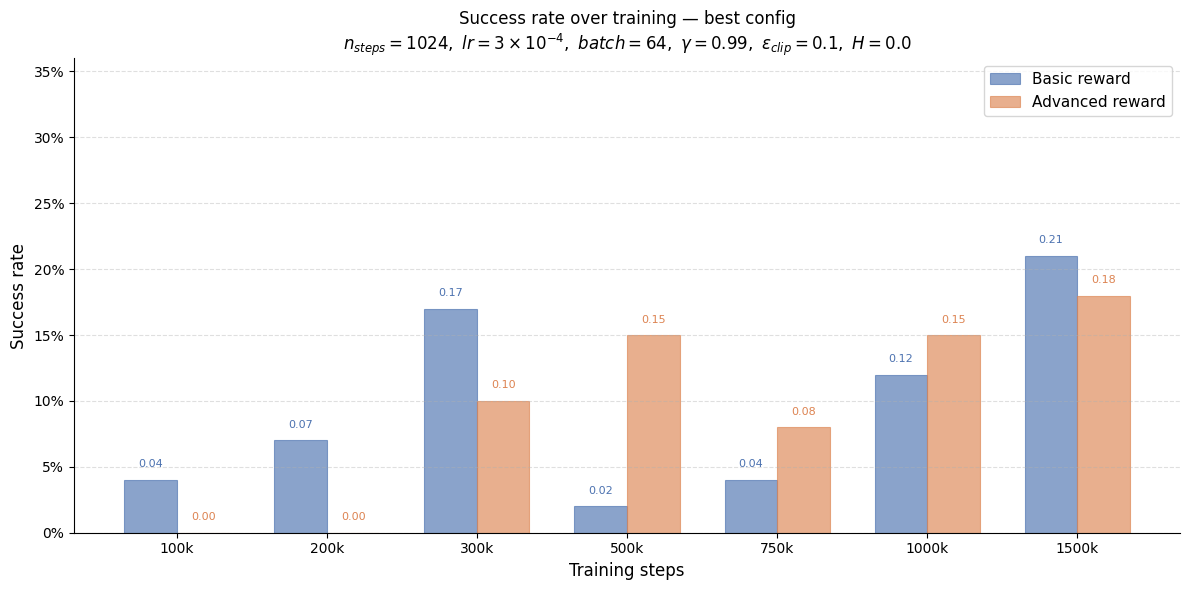

Plot saved → best_config_training/best_config_sr_over_time.png

CSV  saved → best_config_training/best_config_results.csv
Plot saved → best_config_training/best_config_sr_over_time.png
Total time: 50.7 min


In [ ]:
if __name__ == "__main__":
    t0 = time.time()

    results_basic    = train_with_checkpoints("basic")
    results_advanced = train_with_checkpoints("advanced")

    plot_results(results_basic, results_advanced)

    print(f"\nCSV  saved → {CSV_PATH}")
    print(f"Plot saved → {PLOT_PATH}")
    print(f"Total time: {(time.time() - t0) / 60:.1f} min")

## Analysis of Best Configuration Training (Learning Curve)

Tracking the top-performing hyperparameter configuration over 1.5 million timesteps highlights severe instability in the learning process for both reward formulations. While the "basic" reward structure ultimately achieves the highest final success rate of 21% at the 1.5M mark—narrowly beating the "advanced" reward's 18%—its trajectory is extremely volatile, spiking to 17% at 300k steps before abruptly crashing to just 2% at 500k. The "advanced" model exhibits a slower initial learning phase (0% success up to 200k steps) and a marginally smoother climb, but it still suffers a notable regression at 750k steps. Ultimately, this timeline reveals that regardless of the reward type, the agent is highly prone to policy degradation and catastrophic forgetting during extended training, suggesting that early stopping or further algorithmic stabilization is necessary to capture peak performance.

# Conclusion based on all of the experiments

**The Core Problem**
Early high scores don't guarantee long-term stability. The "advanced" model is better overall, but the agent frequently forgets what it learned and relies heavily on lucky starting conditions.

**Why 47% in one test, but 18% in the timeline?**
* **Luck (Seeds):** The 47% run had a lucky starting point that helped it find the right moves fast. The 18% run did not.
* **Fragile Strategies:** Once the agent gets a high score, it repeats that exact sequence. If one tiny random move breaks the sequence later, its success rate crashes.

**Why does performance drop over time?**
* **Short-Term Memory (Catastrophic Forgetting):** If the agnet fails for a stretch, it overwrites and "forgets" its past successful moves.
* **Aggressive Adjustments:** The advanced system gives huge points. The agent gets greedy, makes wild policy updates to chase those points, and ruins good habits.
* **Constant Speed:** The learning rate never slowed down. Instead of fine-tuning, the agent kept making massive, destabilizing changes.

**The Fix**
Don't rely on the final agent model at the end of training. We must save copies continuously and stop training the moment it hits a peak score.

## Eval of best model & Demo

In [1]:
import numpy as np
import gymnasium as gym
import imageio
from IPython.display import Image, Video, display
from stable_baselines3 import PPO

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
import colored_chest_kuka_env

pybullet build time: Oct 21 2025 10:25:59


In [3]:
model_path = "saved_kuka_models_grid/s2_run_17_reward-advanced_nsteps-1024_lr-0p0003_batch-64_gamma-0p99_ent-0p0_clip-0p1_nepochs-10_seed42.zip"
num_eval_episodes = 100

In [4]:
model = PPO.load(model_path)

/home/ensta/ensta-arous/miniconda3/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [5]:
eval_env = gym.make(
    "ColoredChestKuka-v0",
    render_mode=None,
    reward_type="advanced",
    max_steps=150,
)

episode_rewards = []
successes = []

In [6]:
for _ in range(num_eval_episodes):
    obs, info = eval_env.reset()
    done = False
    truncated = False
    total_reward = 0.0

    while not done and not truncated:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = eval_env.step(action)
        total_reward += reward

    episode_rewards.append(total_reward)
    successes.append(int(info.get("is_success", False)))

eval_env.close()

In [7]:
print("Mean reward:", float(np.mean(episode_rewards)))
print("Success rate:", float(np.mean(successes)))
print("Num successes:", int(np.sum(successes)), "/", num_eval_episodes)



Mean reward: 222.5939334313385
Success rate: 0.36
Num successes: 36 / 100


In [8]:
demo_env = gym.make(
    "ColoredChestKuka-v0",
    render_mode="rgb_array",
    reward_type="advanced",
    max_steps=150,
)

frames = []
success_info = None
max_attempts = 300

In [9]:
for attempt in range(1, max_attempts + 1):
    obs, info = demo_env.reset()
    done = False
    truncated = False
    frames_candidate = []

    while not done and not truncated:
        frames_candidate.append(demo_env.render())
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = demo_env.step(action)

    frames_candidate.append(demo_env.render())

    if info.get("is_success", False):
        frames = frames_candidate
        success_info = info
        print(f"Successful demo found on attempt {attempt}")
        break

demo_env.close()

Successful demo found on attempt 1


Success: True
Number of frames: 70
GIF saved as kuka_demo_success.gif
Video saved as kuka_demo_success.mp4


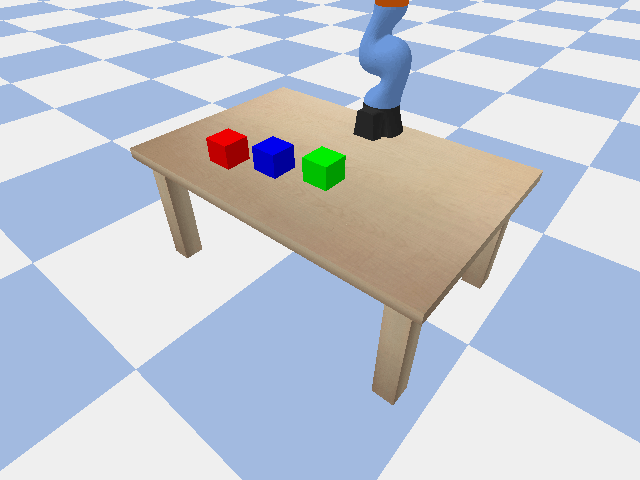

In [10]:
if not frames:
    print("No successful episode found within max_attempts.")
else:
    print("Success:", success_info["is_success"])
    print("Number of frames:", len(frames))

    gif_path = "kuka_demo_success.gif"
    mp4_path = "kuka_demo_success.mp4"

    imageio.mimsave(gif_path, frames, fps=30)
    imageio.mimsave(
        mp4_path,
        [np.asarray(f, dtype=np.uint8) for f in frames],
        fps=30,
        codec="libx264",
        macro_block_size=None,
    )

    print("GIF saved as", gif_path)
    print("Video saved as", mp4_path)

    display(Image(filename=gif_path))
    display(Video(mp4_path, embed=True))